# 0. Setup
    imports, paths, RANDOM_STATE, TEST_SIZE

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(r"C:\ml_eng_prep_2026\project-1-secom-yield")
assert (ROOT / "src" / "load.py").exists(), ROOT
sys.path.insert(0, str(ROOT))

RAW     = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
RANDOM_STATE = 42
TEST_SIZE    = 0.2

pd.set_option("display.max_columns", 50)

In [2]:
with open(RAW / "secom.data") as f:
    print(f.readline()[:300])

with open(RAW / "secom_labels.data") as f:
    for _ in range(3):
        print(f.readline(), end = "")

3030.93 2564 2187.7333 1411.1265 1.3602 100 97.6133 0.1242 1.5005 0.0162 -0.0034 0.9455 202.4396 0 7.9558 414.871 10.0433 0.968 192.3963 12.519 1.4026 -5419 2916.5 -4043.75 751 0.8955 1.773 3.049 64.2333 2.0222 0.1632 3.5191 83.3971 9.5126 50.617 64.2588 49.383 66.3141 86.9555 117.5132 61.29 4.515 7
-1 "19/07/2008 11:55:00"
-1 "19/07/2008 12:32:00"
1 "19/07/2008 13:17:00"


In [3]:
X_raw = pd.read_csv(RAW / "secom.data", sep = " ", header = None)

labels = pd.read_csv(RAW / "secom_labels.data", sep = " ", header = None)

print(X_raw.shape)
print(labels.shape)

(1567, 590)
(1567, 2)


In [4]:
labels.columns = ["label", "timestamp"]

In [5]:
labels["label"].value_counts()


label
-1    1463
 1     104
Name: count, dtype: int64

In [6]:
labels["label"].value_counts(normalize=True)

label
-1    0.933631
 1    0.066369
Name: proportion, dtype: float64

In [7]:
fails = labels[labels["label"]==1] 
passes = labels[labels["label"]==-1]

In [8]:
len(passes) / len(fails)

14.067307692307692

Target: 1,463 pass / 104 fail (6.6% fail), ~14:1 imbalance. Always-pass baseline = 93.4% accuracy, so accuracy is useless. Decisions: stratified split, class weighting, report precision/recall/F1/ROC-AUC.

In [9]:
labels["y"] = (labels["label"] == 1).astype(int)

In [10]:
labels["y"].value_counts()

y
0    1463
1     104
Name: count, dtype: int64

In [25]:
miss_frac = X_raw.isna().mean().sort_values(ascending=False)
miss_frac

292    0.911934
293    0.911934
158    0.911934
157    0.911934
492    0.855775
         ...   
523    0.000000
522    0.000000
521    0.000000
520    0.000000
120    0.000000
Length: 590, dtype: float64

In [26]:
miss_frac.mean()

np.float64(0.04537548808583822)

Missingness: 4.5% overall, but concentrated. Top features are 65–91% missing, in identical-fraction groups (likely whole sensor sets missing together). Decision for Wednesday: set a drop threshold for mostly-empty features; impute the rest.

In [37]:
sample_feats = X_raw.sample(n=9, axis = 1, random_state=42)

In [38]:
sample_feats

,522,284,514,331,210,90,299,181,546
0,29.3804,0.0,0.0,0.0752,0.0772,8671.9301,0.0202,0.333,1.0616
1,26.3970,0.0,0.0,0.0778,0.0566,8407.0299,0.0561,0.439,1.3526
2,14.5293,0.0,0.0,0.0243,0.0339,9317.1698,0.0583,0.745,0.7942
3,13.2699,0.0,0.0,0.0243,0.1248,8205.7000,0.0445,0.693,1.1650
4,18.7319,0.0,0.0,0.0822,0.0915,9014.4600,0.0181,0.282,1.4636
...,...,...,...,...,...,...,...,...,...
1562,7.5149,0.0,0.0,0.0315,NaN,9201.7201,0.0760,0.783,1.2960
1563,6.3391,0.0,0.0,0.0782,NaN,8624.8599,0.0192,0.580,0.8273
1564,16.6608,NaN,0.0,0.0706,NaN,8992.6702,0.0320,0.515,0.8997
1565,16.4179,0.0,0.0,0.0783,NaN,NaN,0.0812,0.980,0.8273


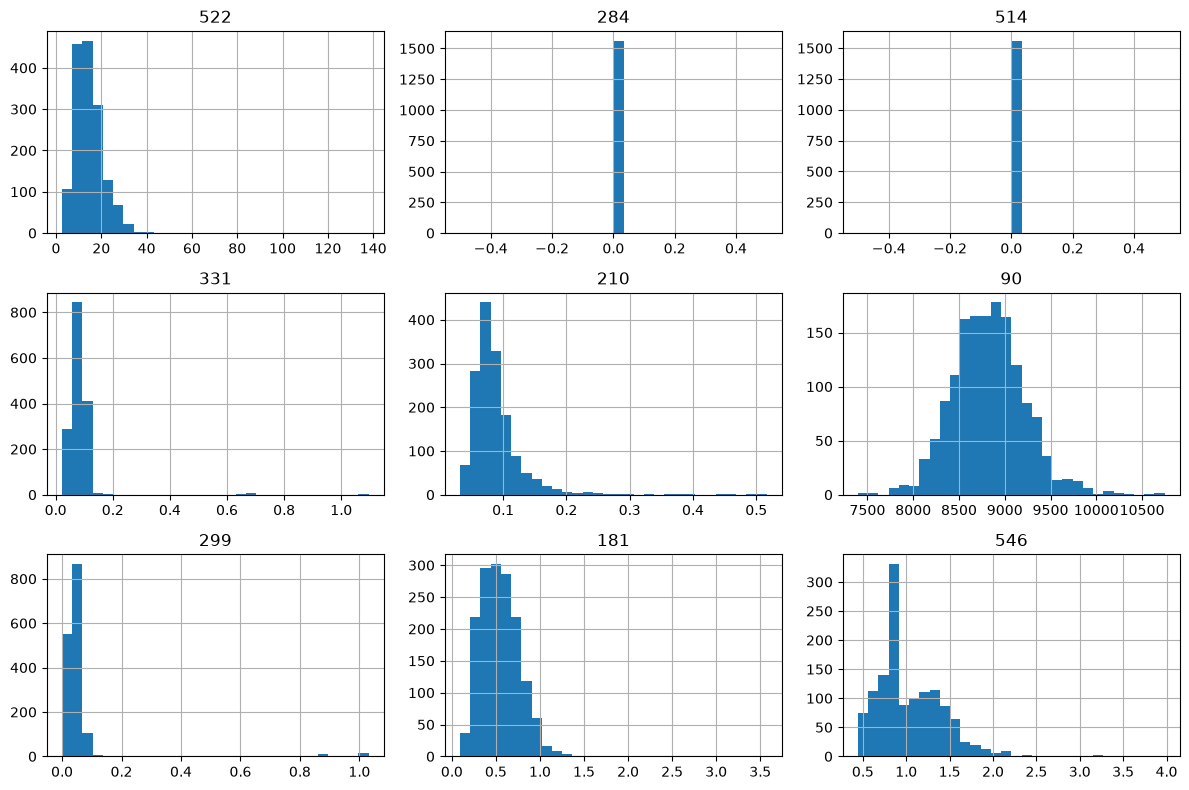

In [36]:
sample_feats.hist(
    bins = 30,
    figsize=(12,8)
)
plt.tight_layout()

In [39]:
sample_feats.describe()

,522,284,514,331,210,90,299,181,546
count,1567.000000,1564.0,1561.0,1563.000000,1543.000000,1516.000000,1565.000000,1566.000000,1307.000000
mean,14.728866,0.0,0.0,0.083232,0.088866,8827.536865,0.060267,0.546770,1.039630
std,7.104435,0.0,0.0,0.063425,0.042065,396.313662,0.130825,0.224402,0.389066
min,2.681100,0.0,0.0,0.022400,0.031900,7397.310000,0.000000,0.093000,0.444400
25%,10.182800,0.0,0.0,0.068800,0.065600,8564.689975,0.030200,0.378000,0.797500
50%,13.742600,0.0,0.0,0.084800,0.079700,8825.435100,0.040000,0.524000,0.911100
75%,17.808950,0.0,0.0,0.095600,0.099450,9065.432400,0.052000,0.688750,1.285550
max,137.983800,0.0,0.0,1.095900,0.516400,10746.600000,1.031200,3.573000,3.978600


Distributions (random 9, seed 42): scales differ ~100,000× (feature 90 ≈ 8.8k vs ~0.08), so scaling is needed for LogReg/MLP, not XGBoost. 2/9 features constant (284, 514), so expect many near-constant features for Wednesday. Mostly right-skewed with outlier clusters (522, 299, 181, 331); keep outliers since they may be process excursions linked to fails. 546 possibly bimodal. Default StandardScaler; RobustScaler as a fallback.